In [1]:
# =========================
# 1. Imports
# =========================
import pandas as pd
import numpy as np
import re
import os
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [2]:
# =========================
# 2. Load Data
# =========================
data = pd.read_csv("amazon_cells_labelled_LARGE_25K.txt", delimiter='\t', header=None)
data.columns = ['Sentence', 'Class']

data['Sentence'] = data['Sentence'].astype(str).str.strip()
texts = data['Sentence'].tolist()
labels = data['Class'].tolist()


# =========================
# 3. Split Data
# =========================
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=SEED
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, stratify=temp_labels, random_state=SEED
)

In [3]:
# =========================
# 4. Tokenization and Vocabulary
# =========================
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
MAX_VOCAB_SIZE = 20000
MIN_FREQ = 2
MAX_SEQ_LEN = 128


def clean_text(text):
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def build_vocab(sentences, min_freq=MIN_FREQ, max_size=MAX_VOCAB_SIZE):
    counter = Counter()
    for sentence in sentences:
        counter.update(sentence.split())
    tokens = [tok for tok, freq in counter.most_common(max_size) if freq >= min_freq]
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for idx, token in enumerate(tokens, start=2):
        vocab[token] = idx
    return vocab


def encode_sentence(sentence, vocab, max_len=MAX_SEQ_LEN):
    tokens = sentence.split()
    token_ids = [vocab.get(token, vocab[UNK_TOKEN]) for token in tokens[:max_len]]
    if len(token_ids) < max_len:
        token_ids += [vocab[PAD_TOKEN]] * (max_len - len(token_ids))
    return token_ids


train_texts = [clean_text(text) for text in train_texts]
val_texts = [clean_text(text) for text in val_texts]
test_texts = [clean_text(text) for text in test_texts]

vocab = build_vocab(train_texts)
pad_idx = vocab[PAD_TOKEN]
unk_idx = vocab[UNK_TOKEN]
vocab_size = len(vocab)
print('Vocabulary size:', vocab_size)

Vocabulary size: 9132


In [4]:
# =========================
# 5. Dataset
# =========================
class MLPDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.inputs = [torch.tensor(encode_sentence(text, vocab), dtype=torch.long) for text in texts]
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.inputs[idx], self.labels[idx]


batch_size = 16
train_loader = DataLoader(MLPDataset(train_texts, train_labels, vocab), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(MLPDataset(val_texts, val_labels, vocab), batch_size=batch_size)
test_loader = DataLoader(MLPDataset(test_texts, test_labels, vocab), batch_size=batch_size)

In [5]:
# =========================
# 6. Model
# =========================
class MLPClassifier(nn.Module):
    """Simple feed-forward neural network for binary text classification."""
    
    def __init__(self, vocab_size, embed_dim=128, hidden_dims=[128, 64], dropout=0.6):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        
        layers = []
        prev = embed_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.fc = nn.Sequential(*layers)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        x = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        x = x.mean(dim=1)      # Average pooling: (batch_size, embedding_dim)
        x = self.fc(x)         # (batch_size, 1)
        return x.squeeze()


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLPClassifier(vocab_size=vocab_size, embed_dim=128, hidden_dims=[128, 64], dropout=0.4).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-6, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print('Using device:', device)
print(model)

Using device: cuda
MLPClassifier(
  (embedding): Embedding(9132, 128, padding_idx=0)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [6]:
# =========================
# 7. Evaluation
# =========================
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == y).sum().item()
            total += y.size(0)

    return 100 * correct / total


# =========================
# 8. Training
# =========================
train_losses = []
val_losses = []
epochs = 500
best_val_loss = float('inf')
best_epoch = 0

os.makedirs('checkpoints', exist_ok=True)

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    val_loss = 0
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            val_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == y).sum().item()
            total += y.size(0)

    avg_train_loss = total_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    scheduler.step(avg_val_loss)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1} Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), f'checkpoints/best_model_epoch_{epoch+1}.pt')
        print(f'Best model saved at epoch {epoch+1}')

Epoch 1 Train Loss: 0.6897 | Val Loss: 0.6712 | Val Acc: 58.96
Best model saved at epoch 1
Epoch 2 Train Loss: 0.6904 | Val Loss: 0.6689 | Val Acc: 59.40
Best model saved at epoch 2
Epoch 3 Train Loss: 0.6877 | Val Loss: 0.6671 | Val Acc: 59.88
Best model saved at epoch 3
Epoch 4 Train Loss: 0.6837 | Val Loss: 0.6670 | Val Acc: 59.36
Best model saved at epoch 4
Epoch 5 Train Loss: 0.6847 | Val Loss: 0.6658 | Val Acc: 59.72
Best model saved at epoch 5
Epoch 6 Train Loss: 0.6838 | Val Loss: 0.6633 | Val Acc: 59.84
Best model saved at epoch 6
Epoch 7 Train Loss: 0.6805 | Val Loss: 0.6617 | Val Acc: 60.76
Best model saved at epoch 7
Epoch 8 Train Loss: 0.6798 | Val Loss: 0.6610 | Val Acc: 60.52
Best model saved at epoch 8
Epoch 9 Train Loss: 0.6776 | Val Loss: 0.6603 | Val Acc: 60.80
Best model saved at epoch 9
Epoch 10 Train Loss: 0.6768 | Val Loss: 0.6586 | Val Acc: 61.56
Best model saved at epoch 10
Epoch 11 Train Loss: 0.6733 | Val Loss: 0.6587 | Val Acc: 61.32
Epoch 12 Train Loss: 0.6

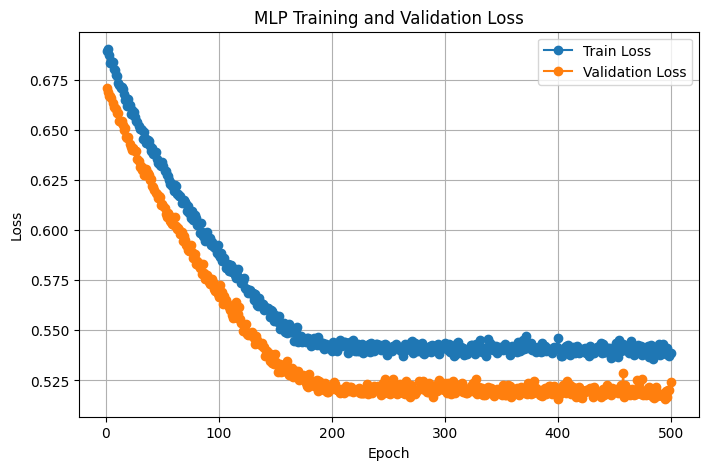

Best epoch: 495 with Val Loss: 0.5156
Test Accuracy: 76.52


In [7]:
# =========================
# 9. Loss Plot
# =========================
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 10. Final Test
# =========================
# Load the best model
model.load_state_dict(torch.load(f'checkpoints/best_model_epoch_{best_epoch}.pt'))
model.eval()

print(f"Best epoch: {best_epoch} with Val Loss: {best_val_loss:.4f}")
test_acc = evaluate(model, test_loader)
print("Test Accuracy:", test_acc)